# Value of Information for Security Decisions

Part 0 introduced EVPI and EVSI with a simple EDR decision tree. This notebook
extends Value of Information (VOI) to realistic security scenarios: when is a
pentest, threat assessment, or additional data collection actually worth paying
for?

The core insight is simple: **information only has value when it can change your
decision.** If you would deploy the same controls regardless of what a pentest
finds, the pentest has zero decision value -- no matter how technically thorough
it is.

This notebook covers:

1. EVPI as the ceiling on what any information source is worth
2. EVSI for an imperfect signal (pentest with known TPR/FPR)
3. When information has zero value
4. VOI as a function of test quality
5. Practical pitfalls

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from decision_security.synth import make_rng, sample
from decision_security.montecarlo import (
    simulate_aggregate_losses, make_lognormal_severity, var_es
)
from decision_security.voi import evpi

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"

## 1. The VOI Question

Before spending $50K on a penetration test, ask: **will the results change my
decision?** If I would deploy the same controls regardless of what the pentest
finds, the information has zero value -- no matter how "important" it seems.

Value of Information (VOI) is the expected improvement in decision quality from
obtaining new data before deciding. It depends on three things:

1. **How uncertain you are** about the state of the world (e.g., breach probability)
2. **How sensitive the decision is** to that uncertainty (e.g., whether a different
   probability would flip your choice)
3. **How accurate the information source is** (e.g., pentest detection rate)

If any of these is near zero, VOI is near zero.

## 2. EVPI: The Ceiling on What Information Is Worth

EVPI (Expected Value of Perfect Information) is the maximum you should pay for
*any* information source -- perfect or imperfect. If a crystal ball that tells
you exactly which scenario will occur is worth $X, then no pentest, threat
assessment, or vulnerability scan can be worth more than $X.

**Scenario:** A CISO is deciding how to handle data exfiltration risk:

- **(A) Full DLP** -- $300K, reduces exfiltration loss by 85%
- **(B) Endpoint-only DLP** -- $120K, reduces exfiltration loss by 50%
- **(C) Accept risk** -- no cost, full exposure

We simulate 10,000 scenarios with an 8% annual exfiltration probability and
lognormal severity.

In [2]:
n = 10_000
severity = make_lognormal_severity(meanlog=13.0, sdlog=1.5)
p_exfil = 0.08

# Simulate whether exfiltration occurs in each scenario
has_exfil = rng.random(n) < p_exfil
exfil_loss = np.where(has_exfil, severity(n, rng), 0)

# Control parameters
cost_full_dlp = 300_000
cost_endpoint = 120_000
reduction_full = 0.85
reduction_endpoint = 0.50

# Total cost per option per scenario
loss_A = cost_full_dlp + exfil_loss * (1 - reduction_full)
loss_B = cost_endpoint + exfil_loss * (1 - reduction_endpoint)
loss_C = exfil_loss

loss_matrix = np.column_stack([loss_A, loss_B, loss_C])

# EVPI: value of knowing exactly which scenario will occur
evpi_val = evpi(loss_matrix)
ev_each = loss_matrix.mean(axis=0)
best_idx = np.argmin(ev_each)
options = ["Full DLP ($300K)", "Endpoint DLP ($120K)", "Accept risk"]

print("Expected cost per option:")
for name, ev in zip(options, ev_each):
    print(f"  {name}: ${ev:,.0f}")
print(f"\nBest option by EV: {options[best_idx]}")
print(f"EVPI: ${evpi_val:,.0f}")
print(f"A perfect oracle saves at most ${abs(evpi_val):,.0f} in expectation")

Expected cost per option:
  Full DLP ($300K): $318,369
  Endpoint DLP ($120K): $181,230
  Accept risk: $122,459

Best option by EV: Accept risk
EVPI: $-86,325
A perfect oracle saves at most $86,325 in expectation


## 3. EVSI: What Is a Pentest Actually Worth?

A penetration test is not a crystal ball. It has a **detection rate** (true
positive rate, TPR) -- how often it correctly flags a real vulnerability that
would lead to exfiltration -- and a **false alarm rate** (FPR) -- how often it
flags a problem that would not actually lead to a loss event.

EVSI (Expected Value of Sample Information) is the expected value of this
imperfect signal. It is always between zero and EVPI:

$$0 \leq |\text{EVSI}| \leq |\text{EVPI}|$$

We model a pentest with 75% TPR and 10% FPR. For each scenario, the pentest
produces either a "high risk" or "low risk" signal. We then compute the optimal
decision conditional on each signal and compare to the unconditional decision.

In [3]:
tpr = 0.75  # P(pentest flags | exfiltration would occur)
fpr = 0.10  # P(pentest flags | no exfiltration)

# Simulate pentest signal for each scenario
signal_positive = np.where(
    has_exfil,
    rng.random(n) < tpr,   # true positive
    rng.random(n) < fpr,   # false positive
)

# EV without information: best unconditional option
ev_no_info = loss_matrix.mean(axis=0).min()

# EV conditional on each signal
ev_pos = loss_matrix[signal_positive].mean(axis=0)
ev_neg = loss_matrix[~signal_positive].mean(axis=0)

best_if_pos = ev_pos.min()
best_if_neg = ev_neg.min()

# EV with information: weighted average of conditional optima
p_pos = signal_positive.mean()
ev_with_info = p_pos * best_if_pos + (1 - p_pos) * best_if_neg

evsi = ev_no_info - ev_with_info

option_labels = ["Full DLP", "Endpoint DLP", "Accept risk"]
print(f"Without pentest: always choose {option_labels[np.argmin(loss_matrix.mean(axis=0))]}")
print(f"  EV = ${ev_no_info:,.0f}")
print(f"\nWith pentest (TPR={tpr}, FPR={fpr}):")
print(f"  If pentest flags HIGH risk ({p_pos:.0%} of the time): choose {option_labels[np.argmin(ev_pos)]}")
print(f"  If pentest flags LOW risk ({1-p_pos:.0%} of the time): choose {option_labels[np.argmin(ev_neg)]}")
print(f"  EV = ${ev_with_info:,.0f}")
print(f"\nEVSI = ${evsi:,.0f}")
print(f"EVPI = ${evpi_val:,.0f}")
if abs(evpi_val) > 0:
    print(f"The pentest captures {abs(evsi/evpi_val):.0%} of the value of perfect information")

Without pentest: always choose Accept risk
  EV = $122,459

With pentest (TPR=0.75, FPR=0.1):
  If pentest flags HIGH risk (15% of the time): choose Full DLP
  If pentest flags LOW risk (85% of the time): choose Accept risk
  EV = $96,304

EVSI = $26,155
EVPI = $-86,325
The pentest captures 30% of the value of perfect information


## 4. When Information Has Zero Value

Sometimes the optimal decision does not change regardless of the test result.
This happens when:

- One option **dominates** across all plausible scenarios
- The decision is **insensitive** to the specific parameter the test measures
- Prior uncertainty is already **low enough** that no signal can flip the choice

We demonstrate by dropping the exfiltration probability to 2%. At this level,
the base rate is so low that even a positive pentest result cannot raise the
posterior risk high enough to justify the DLP investment. Accept-risk wins
regardless of the signal.

In [4]:
# Low-risk scenario: exfiltration probability = 2%
p_exfil_low = 0.02
has_exfil_low = rng.random(n) < p_exfil_low
exfil_loss_low = np.where(has_exfil_low, severity(n, rng), 0)

loss_A2 = cost_full_dlp + exfil_loss_low * (1 - reduction_full)
loss_B2 = cost_endpoint + exfil_loss_low * (1 - reduction_endpoint)
loss_C2 = exfil_loss_low

loss_matrix_2 = np.column_stack([loss_A2, loss_B2, loss_C2])

# Same pentest characteristics
signal_pos_2 = np.where(
    has_exfil_low,
    rng.random(n) < tpr,
    rng.random(n) < fpr,
)

ev_no_info_2 = loss_matrix_2.mean(axis=0).min()
ev_pos_2 = loss_matrix_2[signal_pos_2].mean(axis=0)
ev_neg_2 = loss_matrix_2[~signal_pos_2].mean(axis=0)

p_pos_2 = signal_pos_2.mean()
ev_with_info_2 = p_pos_2 * ev_pos_2.min() + (1 - p_pos_2) * ev_neg_2.min()
evsi_2 = ev_no_info_2 - ev_with_info_2

print(f"Low-risk scenario (P(exfil) = {p_exfil_low}):")
print(f"  Best option WITHOUT pentest: {option_labels[np.argmin(loss_matrix_2.mean(axis=0))]}")
print(f"  Best option IF positive:     {option_labels[np.argmin(ev_pos_2)]}")
print(f"  Best option IF negative:     {option_labels[np.argmin(ev_neg_2)]}")
print(f"  EVSI = ${evsi_2:,.0f}")
print(f"\nThe pentest does not change the decision -- its value is zero.")

Low-risk scenario (P(exfil) = 0.02):
  Best option WITHOUT pentest: Accept risk
  Best option IF positive:     Accept risk
  Best option IF negative:     Accept risk
  EVSI = $-0

The pentest does not change the decision -- its value is zero.


## 5. VOI Across Test Quality

How much should you pay for a better pentest? The relationship between test
quality and information value is not linear. There are **diminishing returns**:
improving TPR from 0.5 to 0.7 matters more than improving from 0.8 to 1.0,
because the marginal scenarios where a better test flips the decision become
rarer.

We sweep TPR from 0.5 to 1.0 (holding FPR at 10%) and plot EVSI at each level.

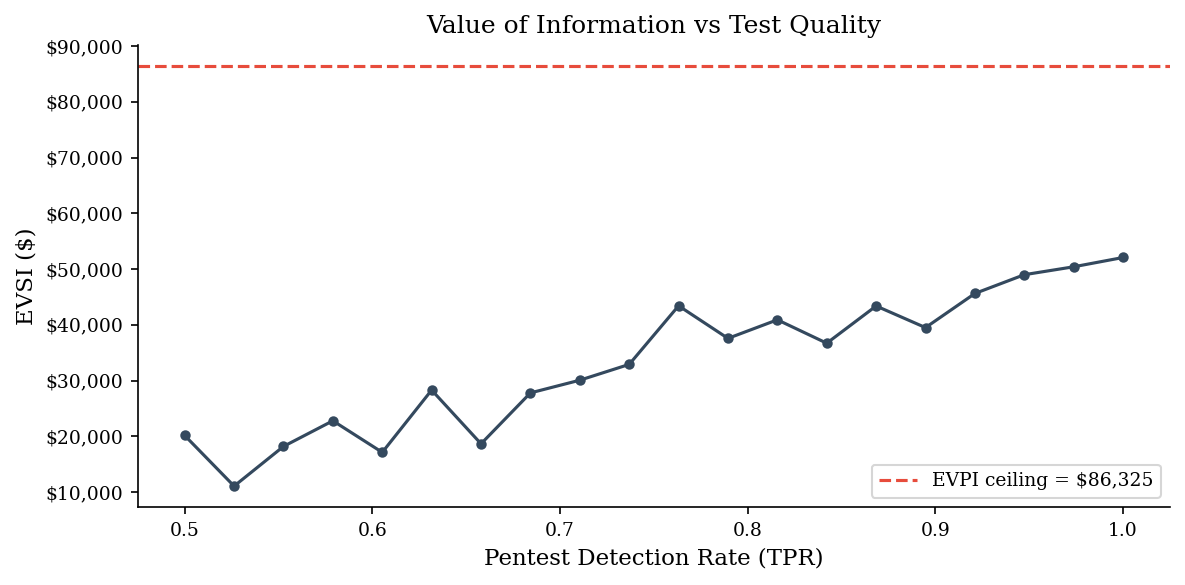

In [5]:
tprs = np.linspace(0.5, 1.0, 20)
evsis = []

for t in tprs:
    sig = np.where(has_exfil, rng.random(n) < t, rng.random(n) < fpr)
    ev_no = loss_matrix.mean(axis=0).min()
    p_s = sig.mean()
    if 0 < p_s < 1:
        ev_w = (
            p_s * loss_matrix[sig].mean(axis=0).min()
            + (1 - p_s) * loss_matrix[~sig].mean(axis=0).min()
        )
    else:
        ev_w = ev_no
    evsis.append(ev_no - ev_w)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tprs, evsis, "o-", color=DARK_BG, markersize=4)
ax.axhline(
    abs(evpi_val), color=ACCENT, linestyle="--",
    label=f"EVPI ceiling = ${abs(evpi_val):,.0f}",
)
ax.set_xlabel("Pentest Detection Rate (TPR)")
ax.set_ylabel("EVSI ($)")
ax.set_title("Value of Information vs Test Quality")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## 6. Pitfalls

- **If the decision does not change, the information is worthless.** Before
  commissioning any assessment, ask: "What would I do differently if the result
  were X vs Y?" If the answer is "nothing," save the money.

- **EVPI is the ceiling, not the target.** No real test achieves perfect
  information. Budget for EVSI, not EVPI.

- **VOI depends on the decision context, not the test quality alone.** A
  mediocre pentest in a close-call scenario can be worth more than a perfect
  pentest in an obvious-choice scenario.

- **Repeated assessments have declining marginal value.** The second pentest of
  the same scope adds less than the first. VOI decreases as prior uncertainty
  shrinks.

- **Sunk cost trap with assessments.** The $50K you already spent on last year's
  assessment is irrelevant to whether this year's assessment is worth $50K.
  Evaluate each information purchase on its marginal decision value.